#### Test pre homing period for replay! 
1. Define prehoming window of 3s, but resample the data in 5ms bins (instead of 25ms) in case the pattern is much faster
2. Search through prehoming periods and find the ones in which 30% of tuned cells are active
3. Rastermap rank order correlation method
4. Bayesian decoding template matching

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]


session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [247]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.escape_utils import load_homing, load_hdir_cells, load_significant_cells
import matplotlib.gridspec as gridspec
from JR_test_scripts.replay.ReplayUtils import pre_homing_bool, make_escape_bool, make_long_homing_bool, df_to_count_array
from JR_test_scripts.replay.BayesianReplay_funcs import bayesian_decoder

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from scipy.stats import zscore
import matplotlib
from syd import make_viewer
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
"""Load the data"""
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Replay/PreHomingSorted")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'
bin_width = 0.01  # 5 ms in seconds
time = 3 # seconds before homing 

# which data?!
e = 17
session_name = session_names[e]
exp = experiments_objects[e]
cond = 1

In [204]:
"""Load tuning data.
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1] # preferred %escape for neurons in each condition
tuning_curve = data['fr_full'] # condition x cell x time

2025-05-08 11:16:53.581 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [205]:
"""Load the spike, behavior and homing data"""
%autoreload 2
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
spike_df = pd.read_csv(os.path.join(base_path, "good_spike_data.csv"))
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))

# extract the condition
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

# load homing
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())

h_start, e_bool = make_escape_bool(h_e_bool, (escape_bool) & (video_df['OutofshelterIdx'].to_numpy()), condition[h_e_bool])
long_homie_bool = make_long_homing_bool(h_start, x_pos[h_e_bool], y_pos[h_e_bool])
prebool, _ = pre_homing_bool(h_e_bool, time, long_homie_bool)

2025-05-08 11:16:56.816 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2025-05-08 11:18:32.044 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [279]:
%autoreload 2
prebool, _ = pre_homing_bool(h_e_bool, time, long_homie_bool)

In [280]:
"""Create array of spike counts in each time bin for each cluster in the prehoming period"""

spike_frames = spike_df['spike_aligned_to_frame'].to_numpy().astype(int)-1
mask = (condition[spike_frames] == cond) & (prebool[spike_frames])
start = np.where(np.diff(prebool.astype(int)) == 1)[0]
end = np.where(np.diff(prebool.astype(int)) == -1)[0]
spike_df_filt = spike_df[mask].copy()

# Create a new column for the time bin index
spike_df_filt['time_bin'] = (spike_df_filt['aligned_spike_times'] // bin_width).astype(int)

# Count spikes for each (cluster, time_bin) pair
count_matrix = pd.pivot_table(
    spike_df_filt,
    index='spike_clusters',    # rows: clusters
    columns='time_bin',        # columns: time bins
    values='aligned_spike_times',
    aggfunc='count',
    fill_value=0
)
# Get all unique cluster IDs from the full spike_df
all_clusters = np.sort(spike_df['spike_clusters'].unique())
count_matrix = count_matrix.reindex(all_clusters, fill_value=0)

# Find gaps in time_bin columns
col_array = np.array(count_matrix.columns)
diffs = np.diff(col_array)
gap_mask = (diffs > 1) & (diffs < 10)

# For each gap, add missing columns
missing_bins = []
for i, is_gap in enumerate(gap_mask):
    if is_gap:
        # Add all missing bins in this gap
        missing = np.arange(col_array[i] + 1, col_array[i + 1])
        missing_bins.extend(missing)

# Add missing columns with zeros
for bin_val in missing_bins:
    count_matrix[bin_val] = 0

# Re-sort columns to maintain order
count_matrix = count_matrix.reindex(sorted(count_matrix.columns), axis=1)

count_array = count_matrix.to_numpy()

# get the starting time bins for each cluster
starts = np.concat([[0],np.where(np.diff(np.array(count_matrix.columns))>1)[0]])
ends = np.concat([np.where(np.diff(np.array(count_matrix.columns))>1)[0], [len(count_matrix.columns)-1]])

#### Looking at sig tuned and untuned neuron actvity

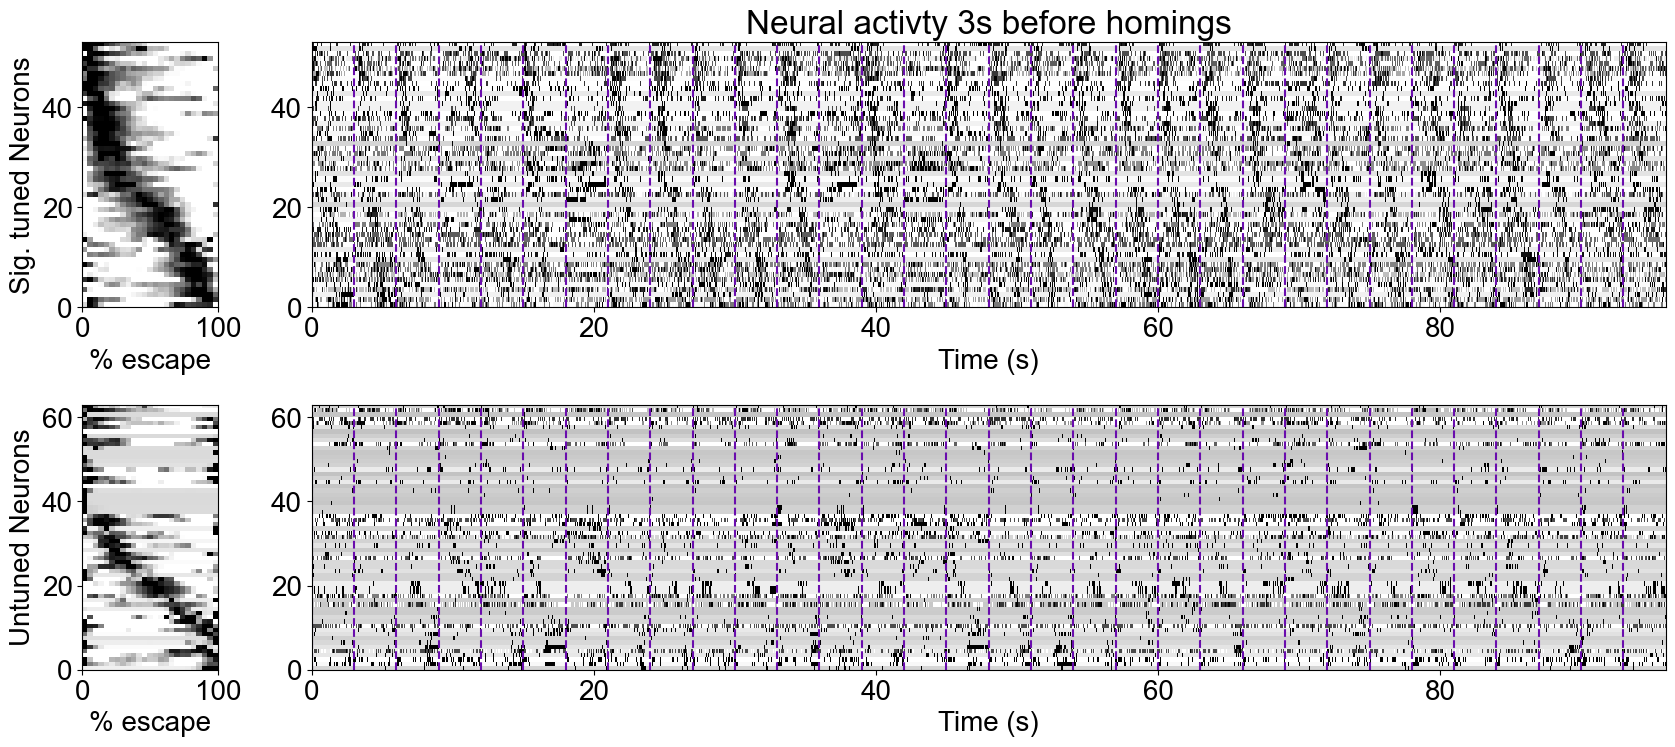

In [ ]:
"""Plot the heatmap of the neural activity and tuning curves"""
width = 350 / 20.4 # mm to inches
height = 200 / 25.4 # mm to inches

# Define trial start times (Example: 5 trials at arbitrary points)
# pull out neural activity for this condition
neural_matrix = count_array.T
neural_matrix = neural_matrix[:,sig_cells[:,cond]] # select the cells that are sig in the condition
neural_matrix = zscore(neural_matrix, axis = 0)

# sort the cells by preferred tuning
pt = tuning_curve[c,sig_cells[:,cond],:] # condition x cell x time
isort = np.argsort(preferred_tuning[sig_cells[:,cond],cond])

# Set up figure with gridspec (one row for XY plots, one for heatmap)
fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(nrows=2, ncols=2, width_ratios = [0.1, 1])

# plot the tuning curves
ax = fig.add_subplot(gs[0, 0])
ax.imshow(zscore(pt[isort,:], axis = 1), vmin=-.5, vmax=1.5, cmap="gray_r", aspect="auto", interpolation="none",
            extent = (0, 100, 0, len(isort)))
ax.set_ylabel("Sig. tuned Neurons")
ax.set_xlabel(r'% escape')

# Create the heatmap
ax_heatmap = fig.add_subplot(gs[0, 1])
ax_heatmap.imshow(neural_matrix[:,isort].T, vmin=-.5, vmax=1.5, cmap="gray_r", aspect="auto", interpolation="none",
                    extent=(0, neural_matrix.shape[0]/(1/bin_width), 0, neural_matrix.shape[1]))
ax_heatmap.set_title(f"Neural activty 3s before homings")
ax_heatmap.set_xlabel('Time (s)')

h_start = np.arange(0, count_array.shape[1]/(1/bin_width), time)
for start, i in enumerate(h_start):    
    # Set limits and plot XY trajectory
    ax_heatmap.axvline(x=i, color=homing_color, linestyle='--')

# add heatmap of neurons that aer not significantly tuned!
neural_matrix = count_array.T
neural_matrix = neural_matrix[:,~sig_cells[:,cond]] # select the cells that are sig in the condition
neural_matrix = zscore(neural_matrix, axis = 0)
pt = tuning_curve[c,~sig_cells[:,cond],:] # condition x cell x time
isort = np.argsort(preferred_tuning[~sig_cells[:,cond],cond])

# plot the tuning curves
ax = fig.add_subplot(gs[1, 0])
ax.imshow(zscore(pt[isort,:], axis = 1), vmin=-.5, vmax=1.5, cmap="gray_r", aspect="auto", interpolation="none",
            extent = (0, 100, 0, len(isort)))
ax.set_ylabel("Untuned Neurons")
ax.set_xlabel(r'% escape')

ax_heatmap = fig.add_subplot(gs[1, 1])
ax_heatmap.imshow(neural_matrix[:,isort].T, vmin=-.5, vmax=1.5, cmap="gray_r", aspect="auto", interpolation="none",
                    extent=(0, neural_matrix.shape[0]/(1/bin_width), 0, neural_matrix.shape[1]))
ax_heatmap.set_xlabel('Time (s)')

h_start = np.arange(0, count_array.shape[1]/(1/bin_width), time)
for start, i in enumerate(h_start):    
    ax_heatmap.axvline(x=i, color=homing_color, linestyle='--')

plt.tight_layout()

### Bayesian decoder method

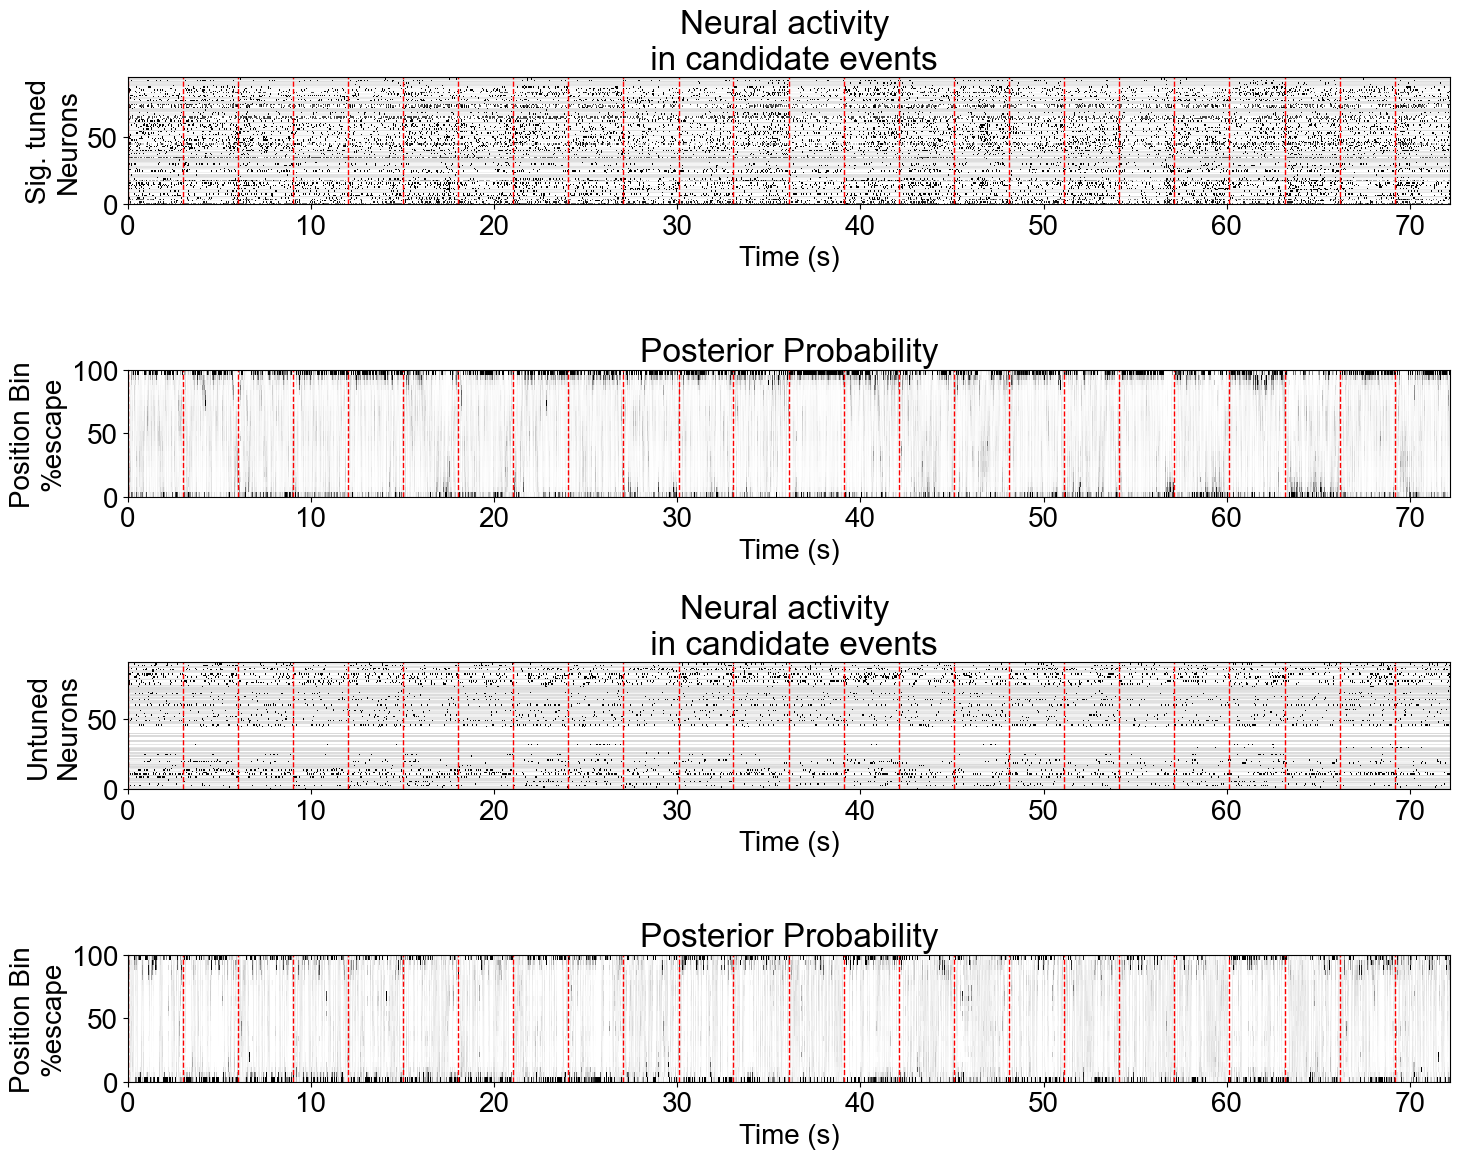

In [278]:
"""Make a plot of all the windows and the bayesian decoded position"""

vmax = .3 # for visualizing the posterior probability

neural_matrix = count_array.T # time x neurons
neural_matrix = neural_matrix[:,sig_cells[:,cond]] # select the cells that are sig in the condition
pt = tuning_curve[cond,sig_cells[:,cond],:] # condition x cell x time
isort = np.argsort(preferred_tuning[sig_cells[:,cond],cond])
neural_matrix = neural_matrix[:,isort] # sort by preferred tuning

firing_rate_maps = data['fr_full'][cond,sig_cells[:,cond],:] # tuning curves for each neuron
firing_rate_maps = firing_rate_maps[isort,:] # sort by pref tuning

# set up some variables
n_position_bins = firing_rate_maps.shape[1]

# Define position bins (replace with your actual bins)
max_fract = 100
position_bin_edges = np.linspace(0, max_fract, n_position_bins + 1)

# Define parameters
fract_thresh = 10.0 # Threshold of fraction of route in percent

# Define parameter search ranges (adjust based on expected replay speeds/positions)
# Velocity range (e.g., -10 m/s to +10 m/s, 101 steps) -> -1000 cm/s to 1000 cm/s
V_range = [-50, 50, 51]
# Starting position range (e.g., full track length, 100 steps)
rho_range = [0, max_fract, 100]
occupancy_map = np.ones(n_position_bins) / n_position_bins # Uniform prior

# make the plot
fig, ax = plt.subplots(4, 1, figsize=(15, 12))

# plot sig cells
ax[0].imshow(zscore(neural_matrix, axis=0).T, vmin=-.5, vmax=1.5, aspect = 'auto', origin = 'lower', interpolation = 'none', cmap = 'Greys',
             extent=(0, neural_matrix.shape[0]/(1/bin_width), 0, neural_matrix.shape[1]))
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Sig. tuned\nNeurons')
ax[0].set_title('Neural activity \n in candidate events')
for i in (starts/(1/bin_width)):
    ax[0].axvline(i, color = 'red', linestyle = '--', linewidth = 1)

posterior = bayesian_decoder(firing_rate_maps, neural_matrix, occupancy_map, bin_width, neural_matrix.shape[0], n_position_bins)
ax[1].imshow(posterior.T, aspect='auto', origin='lower', interpolation='none', cmap = 'Greys', vmin = 0, vmax = vmax,
             extent=[0, neural_matrix.shape[0]/(1/bin_width), 0, max_fract])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Position Bin\n' + r'%escape')
ax[1].set_title('Posterior Probability')
for i in (starts/(1/bin_width)):
    ax[1].axvline(i, color = 'red', linestyle = '--', linewidth = 1)

# plot non sig cells

neural_matrix = count_array.T # time x neurons
neural_matrix = neural_matrix[:,~sig_cells[:,cond]] # select the cells that are sig in the condition
pt = tuning_curve[cond,~sig_cells[:,cond],:] # condition x cell x time
isort = np.argsort(preferred_tuning[~sig_cells[:,cond],cond])
neural_matrix = neural_matrix[:,isort] # sort by preferred tuning

firing_rate_maps = data['fr_full'][cond,~sig_cells[:,cond],:] # tuning curves for each neuron
firing_rate_maps = firing_rate_maps[isort,:] # sort by pref tuning

ax[2].imshow(zscore(neural_matrix, axis=0).T, vmin=-.5, vmax=1.5, aspect = 'auto', origin = 'lower', interpolation = 'none', cmap = 'Greys',
             extent=(0, neural_matrix.shape[0]/(1/bin_width), 0, neural_matrix.shape[1]))
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Untuned\nNeurons')
ax[2].set_title('Neural activity \n in candidate events')
for i in (starts/(1/bin_width)):
    ax[2].axvline(i, color = 'red', linestyle = '--', linewidth = 1)

posterior = bayesian_decoder(firing_rate_maps, neural_matrix, occupancy_map, bin_width, neural_matrix.shape[0], n_position_bins)
ax[3].imshow(posterior.T, aspect='auto', origin='lower', interpolation='none', cmap = 'Greys', vmin = 0, vmax = vmax,
             extent=[0, neural_matrix.shape[0]/(1/bin_width), 0, max_fract])
ax[3].set_xlabel('Time (s)')
ax[3].set_ylabel('Position Bin\n' + r'%escape')
ax[3].set_title('Posterior Probability')
for i in (starts/(1/bin_width)):
    ax[3].axvline(i, color = 'red', linestyle = '--', linewidth = 1)

plt.tight_layout()

#### Rank order correlation method

In [ ]:
"""Let's syd it"""

def plot(state):

    win = starts[state['window idx']]
    n_window = fcm[win:win+window_samples,:]

    fig, axs = plt.subplots(2, 3, figsize=(20, 10), height_ratios = [.5,5])

    axs[0,0].plot(h_e_bool[win:win+window_samples], color = homing_color)
    axs[0,0].set_ylim(-.5, 1.5)
    axs[0,0].set_yticks([0,1])
    axs[0,0].set_xticks([])
    axs[0,0].set_xlim(0, window_samples)
    axs[0,0].spines['right'].set_visible(False)
    axs[0,0].spines['top'].set_visible(False)
    axs[0,0].spines['bottom'].set_visible(False)

    axs[1,0].imshow(n_window.T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
    axs[0,0].set_title('Best window \n' + r'sorted on %escape tuning', fontsize = 30)

    event_seq = generate_event_seq(n_window, state['zscore_thresh'], window_samples, method = state['method'])

    axs[1,1].imshow(n_window[:,event_seq].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
    axs[0,1].set_title('Best window \n sorted on activity in event', fontsize = 30)
    axs[0,1].set_axis_off()

    axs[1,2].scatter(np.arange(n_window.shape[1]), event_seq)
    correlation, p_value = spearmanr(np.arange(n_window.shape[1]), event_seq)

    axs[0,2].set_title(f"Rank correlation: {correlation:.3f}" + '\n' + f"p-value: {p_value:.5f}", fontsize = 30)
    axs[0,2].set_axis_off()
    axs[1,2].set_xlabel("Template order")
    axs[1,2].set_ylabel("Activation Order")
    axs[1,2].set_box_aspect(1)
    axs[1,2].set_xticks([])
    axs[1,2].set_yticks([])

    plt.tight_layout()
    return fig

viewer = make_viewer()
viewer.add_integer('window idx', min = 0, max = len(starts))
viewer.add_integer('zscore_thresh', min = 1, max = 5)
viewer.add_selection(name = 'method', options = ['first_activity', 'weighted_avg', 'rastermap'])

viewer.set_plot(plot)
viewer.show()

#### Template warping method

#### Spike triggered average method

In [ ]:
# Let's start by doing this in the spike_df_filt that we generated that only includes homing periods
all_clusters = np.sort(spike_df['spike_clusters'].unique())

STA_bin = 0.01 # seconds
STA_range = .5 # seconds
spike_df_filt['STA_time_bin'] = (spike_df_filt['aligned_spike_times'] // STA_bin).astype(int)

count_array = np.zeros((len(all_clusters), (2*int(STA_range/STA_bin))+1,sig_cells.shape[0]))
num_spikes = np.zeros(sig_cells.shape[0])

# Step 1: Iterate over significantly tuned neurons in the condition
for i, neuron in enumerate(sig_cells[:,cond]):
    if neuron:
        # Step 2: For each neuron, find each spike and then in time bins of 5 or 10 ms, count the number of spikes of every other neuron 
        # (only do this for the neurons that are significantly tuned in the condition)
        # (do this for a window of 1s before and after each spike)
        spike_this_clust = spike_df_filt[spike_df_filt['spike_clusters'] == all_clusters[i]]
        num_spikes[i] = len(spike_this_clust)
        # check that spike_this_clust is not empty
        if not spike_this_clust.empty:
            # Step 3: For each spike, find the time bin of the spike and then count the number of spikes of every other neuron in that time bin
            # (do this for a window of 1s before and after each spike)
            for j, row in spike_this_clust.iterrows():
                # Get the time bin of the spike
                time_bin = int(row['STA_time_bin'])
                # identify the STA_time bins that go from -1s to +1s around the spike
                start_bin = time_bin - int(STA_range/STA_bin)
                end_bin = time_bin + int(STA_range/STA_bin)
                # Step 4: Iterate over time bins from start_bin to end_bin and count the number of spikes of every other neuron in that time bin
                df_around_spike = spike_df_filt[(spike_df_filt['STA_time_bin'] >= start_bin) & (spike_df_filt['STA_time_bin'] <= end_bin)]
                # df_around_spike = df_around_spike[df_around_spike['spike_clusters'] != all_clusters[i]]
                count_matrix = df_to_count_array(df_around_spike, all_clusters, 'STA_time_bin', fill_time = [start_bin, end_bin])
                count_array[:,:,i] += count_matrix.to_numpy()
            # count_array = count_array/j


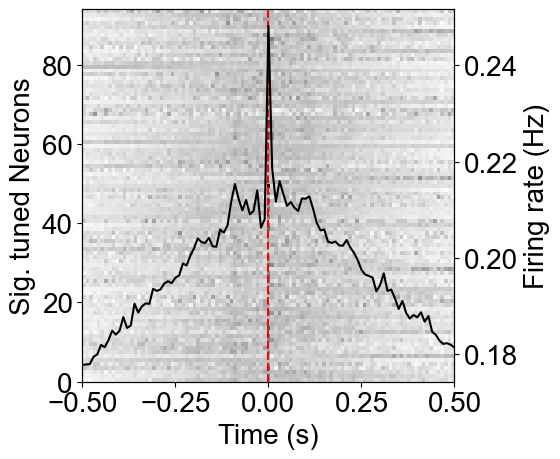

In [365]:
fig,ax = plt.subplots(1, 1, figsize=(6, 5))
i = 61
isort = np.argsort(preferred_tuning[sig_cells[:,cond],cond])
ax.imshow(zscore(count_array[isort,:,i], axis=1), aspect = 'auto', cmap = 'Greys', interpolation = 'none',
          extent = (-STA_range, STA_range, 0, len(isort)))
ax.set_ylabel("Sig. tuned Neurons")
# use the right y axis to plot the tuning curve
ax2 = ax.twinx()
ax2.axvline(x=0, color = 'red', linestyle = '--')
ax2.plot(np.arange(-STA_range,STA_range+STA_bin, STA_bin), np.mean(count_array[isort,:,i], axis = 0)/num_spikes[i], color = 'black')
ax2.set_ylabel('Firing rate (Hz)')
ax.set_xlabel('Time (s)')
plt.tight_layout()